Contol Dataset

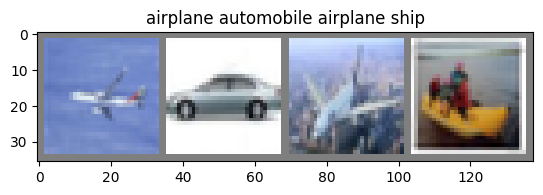

In [ ]:
import torchvision.transforms as transforms
import torchvision
import matplotlib.pyplot as plt
import torch
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import Dataset, DataLoader
import csv

# from geekforgeek website
test_set = torchvision.datasets.CIFAR10(root='./data', 
                                        train=False, 
                                        download=True,
                                        transform=transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]))
testloader = torch.utils.data.DataLoader(test_set,
                                          batch_size=4, 
                                          shuffle=True)

images, labels = next(iter(testloader))

plt.imshow(torchvision.utils.make_grid(images).permute(1, 2, 0) / 2 + 0.5); 
plt.title(' '.join(test_set.classes[label] for label in labels)); plt.show()

Generating the control data

The control dataset will act as a wrapper for the pytorch dataset class for memory efficiency (lazy loading). To accomplish this, we must extend the __len__ class and the __getitem__ class which are required in order to work with the torch DataLoader.

In [2]:
# import class for creating the control dataset
from control_dataset_shift import ControlShiftDataset


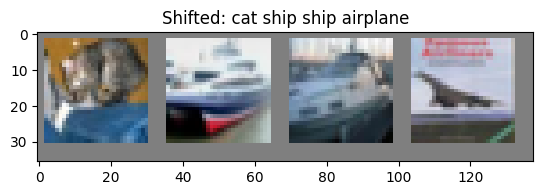

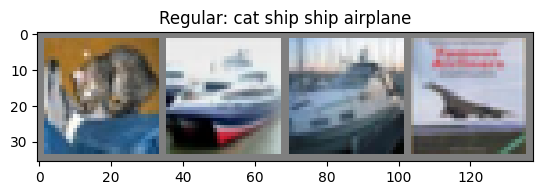

In [3]:
# checking shifted images

test_set_shift_3 = ControlShiftDataset(test_set, direction='up-left', shift=3, edge_correction=False)
shifted_loader = DataLoader(test_set_shift_3, batch_size=4, shuffle=False)

# visualise
shifted_images, shifted_labels = next(iter(shifted_loader))
plt.imshow(torchvision.utils.make_grid(shifted_images).permute(1, 2, 0) / 2 + 0.5)
plt.title('Shifted: ' + ' '.join(test_set.classes[label] for label in shifted_labels))
plt.show()

test_set_no_shift = test_set
loader = DataLoader(test_set_no_shift, batch_size=4, shuffle=False)

# visualise
images, labels = next(iter(loader))
plt.imshow(torchvision.utils.make_grid(images).permute(1, 2, 0) / 2 + 0.5)
plt.title('Regular: ' + ' '.join(test_set.classes[label] for label in labels))
plt.show()




Notes on the shifting observations: 
- not a good idea to shift more than 5 pixels as that might move a significant amount of the target out of the picture

# Testing the control dataset

In [4]:
#standard_cnn = resnet18(weights=ResNet18_Weights.DEFAULT) # for imagenet :(
resnet18_model = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar10_resnet20", pretrained=True)
resnet18_model.eval()
device = torch.device("cpu")
resnet18_model = resnet18_model.to(device)

Using cache found in /home/vic/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master


In [5]:
# import the testing function
from control_dataset_shift import test_shift_invariance

In [6]:
clean_loader = torch.utils.data.DataLoader(test_set_no_shift, batch_size=64, shuffle=True)

shift_pixels_param = 4
direction_param = 'down-left'
edge_correction_param = False
test_set_shift= ControlShiftDataset(test_set, direction=direction_param, shift=shift_pixels_param, edge_correction=edge_correction_param)
shifted_loader = torch.utils.data.DataLoader(test_set_shift, batch_size=64, shuffle=True)

print("Resnet18 on original dataset:")
clean_acc = test_shift_invariance(resnet18_model, clean_loader, device)
print("-" * 50)
print(f"Original Accuracy: {clean_acc:.2f}%\n\n")

print(f"Resnet on {shift_pixels_param}-pixel shifted data in {direction_param} direction with edge correction {edge_correction_param}:")
shifted_acc = test_shift_invariance(resnet18_model, shifted_loader, device)

print("-" * 50)
print(f"Shifted Accuracy:  {shifted_acc:.2f}%")
print(f"Accuracy Drop:     {(clean_acc - shifted_acc):.2f}%")

Resnet18 on original dataset:
--------------------------------------------------
Original Accuracy: 81.13%


Resnet on 4-pixel shifted data in down-left direction with edge correction False:
--------------------------------------------------
Shifted Accuracy:  73.67%
Accuracy Drop:     7.46%


In [7]:
shifts = [0, 1, 2, 3, 4] # 0 is baseline
directions = ['up-left', 'left', 'down-left', 'up-right', 'right', 'down-right']
results = {direction: [] for direction in directions}

# evaluate baseline
clean_loader = torch.utils.data.DataLoader(test_set_no_shift, batch_size=128, shuffle=True)
baseline_acc = test_shift_invariance(resnet18_model, clean_loader, device)

for direction in directions:
    results[direction].append(baseline_acc) 
    
    for shift_val in [1, 2, 3, 4]:
        print(f"running direction={direction}, shift={shift_val}px")
        
        # temporary 
        temp_dataset = ControlShiftDataset(test_set, direction=direction, shift=shift_val, edge_correction=False)
        temp_loader = torch.utils.data.DataLoader(temp_dataset, batch_size=128, shuffle=False)
        
        acc = test_shift_invariance(resnet18_model, temp_loader, device)
        results[direction].append(acc)


with open("results.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["direction", "shift", "accuracy"])
    for direction, accs in results.items():
        for shift_val, acc in zip(shifts, accs):
            writer.writerow([direction, shift_val, f"{acc:.4f}"])

running direction=up-left, shift=1px
running direction=up-left, shift=2px
running direction=up-left, shift=3px
running direction=up-left, shift=4px
running direction=left, shift=1px
running direction=left, shift=2px
running direction=left, shift=3px
running direction=left, shift=4px
running direction=down-left, shift=1px
running direction=down-left, shift=2px
running direction=down-left, shift=3px
running direction=down-left, shift=4px
running direction=up-right, shift=1px
running direction=up-right, shift=2px
running direction=up-right, shift=3px
running direction=up-right, shift=4px
running direction=right, shift=1px
running direction=right, shift=2px
running direction=right, shift=3px
running direction=right, shift=4px
running direction=down-right, shift=1px
running direction=down-right, shift=2px
running direction=down-right, shift=3px
running direction=down-right, shift=4px


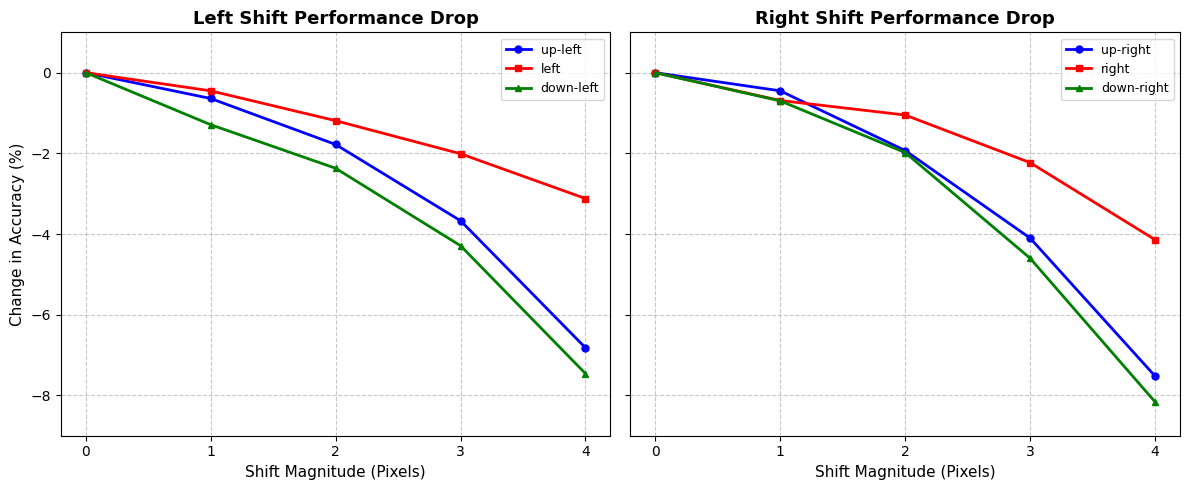

In [12]:
left_direction = [d for d in directions if "left" in d and "right" not in d]
right_directions = [d for d in directions if "right" in d and "left" not in d]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

markers = ['o', 's', '^', 'D', 'x', 'P']
colors = ['blue', 'red', 'green']

def plot_trend(ax, dirs, title):
    for idx, direction in enumerate(dirs):
        baseline = results[direction][0]
        accuracy_change = [acc - baseline for acc in results[direction]]
        ax.plot(
            shifts,
            accuracy_change,
            marker=markers[idx % len(markers)],
            color=colors[idx % len(colors)],
            linewidth=2,
            markersize=5,
            label=direction,
        )
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Shift Magnitude (Pixels)', fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.set_ylim(bottom=-9, top=1)
    ax.set_xticks(shifts)
    ax.legend(fontsize=9)


plot_trend(axes[0], left_direction, 'Left Shift Performance Drop')
axes[0].set_ylabel('Change in Accuracy (%)', fontsize=11)
plot_trend(axes[1], right_directions, 'Right Shift Performance Drop')

plt.tight_layout()
plt.show()